In [111]:
# Felix Shyann  

In [96]:
import pandas as pd

df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


6 Hypotheses
------------

2 Hypotheses for t-test
One binary categorical variable (e.g., smoker vs non-smoker, male vs female)
One numerical variable
-----------------------------------------------------------------------------
H₀: There is no difference in average poor mental health days between people with and without high blood pressure.
H₁: There is a difference in average poor mental health days between people with and without high blood pressure.


H₀: There is no difference in average income level between those with and without a history of heart disease or attack.
H₁: There is a difference in average income level between those with and without a history of heart disease or attack.

-----------------------------------------------------------------------------------------

2 Hypotheses for Chi-square test
These must involve two categorical variables.
-----------------------------------------------
H₀: Stroke history and high cholesterol status are independent.
H₁: Stroke history and high cholesterol status are associated.


H₀: Sex and heavy alcohol consumption are independent.
H₁: Sex and heavy alcohol consumption are associated.

-----------------------------------------------------------------------------------------

2 Hypotheses for linear regression
Each must involve:
One numerical outcome variable
One main independent variable 
Please state what control variables will be in this model (including at least two).
-----------------------------------------------------------------------------------

H₀: There is no linear relationship between education and income. The control variables are age and sex.
H₁: There is a linear relationship between education and income. The control variables are age and sex.


H₀: There is no linear relationship between alcohol and BMI. The control variables are physical activity and age.
H₁: There is a linear relationship between alcohol and BMI. The control variables are physical activity and age.






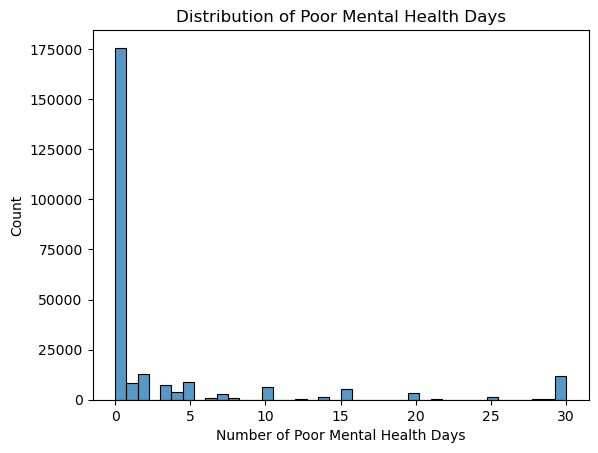

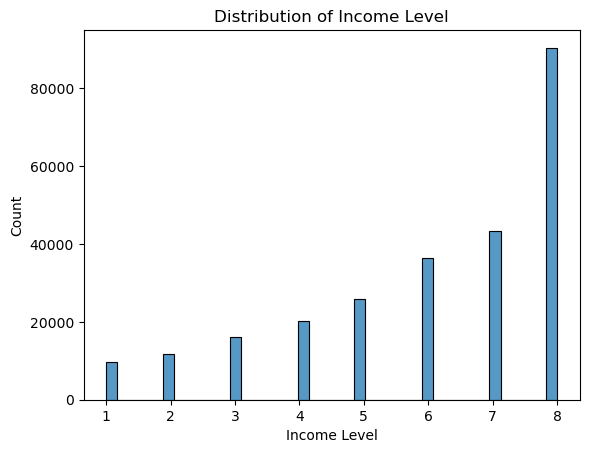

In [97]:
# histogram for normal distribution check before running t-test
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.histplot(data=df, x="MentHlth", bins=40)
plt.title("Distribution of Poor Mental Health Days")
plt.xlabel('Number of Poor Mental Health Days')
plt.ylabel('Count')
plt.show()

sns.histplot(data=df, x="Income", bins=40)
plt.title("Distribution of Income Level")
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()


Observation: 
--

Both MentHlth (right-skewed) and Income (left-skewed) are not normally distributed. 
However, given the very large sample size in this dataset, I think a T-test is still appropriate.

In [98]:
#T-test 

from scipy.stats import ttest_ind

# T-test 1: MentHlth by HighBP
ttest_ind(df[df['HighBP'] == 0]['MentHlth'], df[df['HighBP'] == 1]['MentHlth'])


TtestResult(statistic=-28.4802685212808, pvalue=3.934049532857432e-178, df=253678.0)

In [99]:
# T-test 2: Income by HeartDiseaseorAttack
ttest_ind(df[df['HeartDiseaseorAttack'] == 0]['Income'], df[df['HeartDiseaseorAttack'] == 1]['Income'])

TtestResult(statistic=71.73917952691698, pvalue=0.0, df=253678.0)

**Observations on t-test 1:**
-

Based on the P value of test 1 p <0.05, so we reject the Null hypothesis, and it indicates that
There is a difference in average poor mental health days between people with and without high blood pressure.

**Observations on t-test 2:**
-

Based on the P value of 0.0, it is less than 0.05, so we reject the Null hypothesis, and it indicates that
There is a difference in average income level between those with and without a history of heart disease or attack.


In [100]:
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [101]:
# Chi-square test 1: Stroke and HighChol
from scipy.stats import chi2_contingency

chi2, p, dof, ex = chi2_contingency(pd.crosstab(df['Stroke'], df['HighChol']))

print("chi2 = ", chi2)
print("p = ", p)
print("degrees of freedom = ", dof)
print("expected = ", ex)

chi2 =  2175.238543765782
p =  0.0
degrees of freedom =  1
expected =  [[140162.05271208 103225.94728792]
 [  5926.94728792   4365.05271208]]


In [102]:
#TABLE 1
observations_1 = pd.crosstab(index=df["Stroke"], columns=df["HighChol"], margins=True)
observations_1

HighChol,0.0,1.0,All
Stroke,,,
0.0,142453,100935,243388
1.0,3636,6656,10292
All,146089,107591,253680


**Observations for observations 1: **
------------------------------------

Based on the test of independence, the p-value is 0, which means I reject the Null and conclude that Stroke history and high cholesterol status are associated.

Based on the table, majority of individuals dont have strokes and dont have high cholesterol

In [103]:
# Chi-square test 2: Sex and HvyAlcoholConsump
chi2, p, dof, ex = chi2_contingency(pd.crosstab(df['Sex'], df['HvyAlcoholConsump']))

print("chi2 = ", chi2)
print("p = ", p)
print("degrees of freedom = ", dof)
print("expected = ", ex)

chi2 =  8.308652767770589
p =  0.003945664773080948
degrees of freedom =  1
expected =  [[133995.51788079   7978.48211921]
 [105428.48211921   6277.51788079]]


In [104]:
#TABLE 2
observations_2 = pd.crosstab(index=df["Sex"], columns=df["HvyAlcoholConsump"], margins=True)
observations_2

HvyAlcoholConsump,0.0,1.0,All
Sex,,,
0.0,134162,7812,141974
1.0,105262,6444,111706
All,239424,14256,253680


**Observations for observations 2:**
-

Based on the test of independence, the p-value is 0.004, which is less than 0.05, so I reject the null hypothesis and conclude that sex and heavy alcohol consumption are associated.

Based on the table, the majority of the data in the table indicates that females(represented by '0')  do not have heavy alcohol consumption

-----------------------------------------------------------------------------------------

**linear regression hypotheses 1:**
-
**Independent**: Education

**Dependent**: Income

**Control variables**: age and sex

<Axes: xlabel='Income', ylabel='Education'>

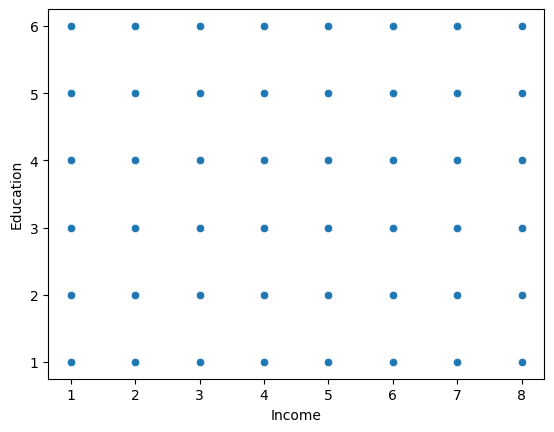

In [105]:
import seaborn as sns

sns.scatterplot(data = df,
                x = 'Income', 
                y = 'Education')

In [106]:
df[['Income', 'Education']].corr()


,Income,Education
Income,1.000000,0.449106
Education,0.449106,1.000000


**Observations scatter plot 1:**
-
The scatter plot is hard to read, and at first glance, there seems to be no relationship between the variables, but upon closer inspection using a correlation check, there appears to be a positive relationship between Income and Education level.

In [107]:
import pingouin as pg

mod1 = pg.linear_regression(df[['Education', 'Age', 'Sex']], df['Income'])
mod1

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,1.620060,0.022371,72.418660,0.0,0.222031,0.222021,1.576213,1.663906
1,Education,0.921721,0.003699,249.170296,0.0,0.222031,0.222021,0.914470,0.928971
2,Age,-0.054175,0.001194,-45.366607,0.0,0.222031,0.222021,-0.056515,-0.051834
3,Sex,0.485678,0.007310,66.439954,0.0,0.222031,0.222021,0.471350,0.500005


**Report of findings from linear regression 1:** 
-

**Education** -Has a positive relationship with the dependent variable, with a coefficient of 0.92. Meaning as Education goes up, the dependent variable goes up. This variables p value is 0 which is less than 0.05 which indicates that we reject the null hypothesis and conclude that there is a statistically significant relationship with the dependent variable.

**Age** - Has a negative relationship with the dependent variable, with a coefficient of -0.05. Meaning that as Age goes up, the dependent variable goes down. This variables p value is 0 which is less than 0.05 which indicates that we reject the null hypothesis and conclude that there is a statistically significant relationship with the dependent variable.

**Sex** - Has a positive relationship with the dependent variable, with a coefficient of 0.49. Meaning as Sex goes up, the dependent variable goes up. This variables p value is 0 which is less than 0.05 which indicates that we reject the null hypothesis and conclude that there is a statistically significant relationship with the dependent variable.
    

**SEPERATE CELL FOR R SQUARED:**
--
According to the table above, 22% of the variance in income is explained by the variables Education, Age, and sex.

**linear regression hypotheses 2**
--
**Independent**: HvyAlcoholConsump

**Dependent**: BMI

**Control variables**: PhysActivity and Age

<Axes: xlabel='HvyAlcoholConsump', ylabel='BMI'>

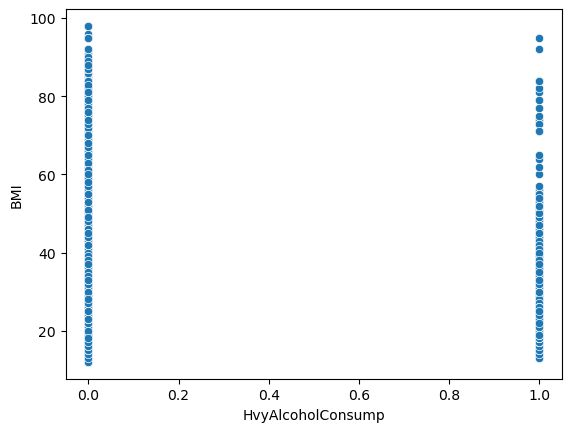

In [108]:
import seaborn as sns

sns.scatterplot(data = df,
                x = 'HvyAlcoholConsump', 
                y = 'BMI')

In [109]:
df[['HvyAlcoholConsump', 'BMI']].corr()


,HvyAlcoholConsump,BMI
HvyAlcoholConsump,1.000000,-0.048736
BMI,-0.048736,1.000000


**Observations scatter plot 2:**
-
This scatter plot is also hard to read as HvyAlcoholConsump is a binary variable so the plot forms around the numbers 0 or 1 instead of in a group correlation. At first glance, it is hard to tell whether or not there is a relationship between the variables, but upon closer inspection using another correlation check, there appears to be a negative but weak relationship between HvyAlcoholConsump and BMI.

In [110]:
import pingouin as pg

mod2 = pg.linear_regression(df[['HvyAlcoholConsump', 'PhysActivity', 'Age']], df['BMI'])
mod2

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,31.135446,0.044985,692.123371,0.000000e+00,0.026607,0.026596,31.047276,31.223616
1,HvyAlcoholConsump,-1.396554,0.056247,-24.828849,6.368923e-136,0.026607,0.026596,-1.506797,-1.286311
2,PhysActivity,-2.333391,0.030295,-77.021315,0.000000e+00,0.026607,0.026596,-2.392769,-2.274013
3,Age,-0.113207,0.004259,-26.579122,1.936356e-155,0.026607,0.026596,-0.121555,-0.104859


**Report of findings from linear regression 2:**
-
**HvyAlcoholConsump** - Has a negative relationship with the dependent variable as the coefficient is -1.40, meaning as HvyAlcoholConsump goes up, the dependent variable goes down. This variable's p-value is p<0.05, indicating that we reject the null hypothesis and conclude that there is a statistically significant relationship with the dependent variable.

**PhysActivity** - Has a negative coefficient of -2.33, showing a negative relationship between PhysActivity and the dependent variable, meaning as PhysActivity goes up, the dependent variable goes down. PhysActivity has a p value of 0, which is less than 0.05, and indicates that we reject the null hypothesis and conclude that there is a statistically significant relationship with the dependent variable.

**Age** - Also has a negative coefficient of -0.11, showing a negative relationship between Age and the dependent variable, meaning as Age goes up, the dependent variable goes down. Age has a p value of less then 0.05, which indicates that we reject the null hypothesis and conclude that there is a statistically significant relationship with the dependent variable.

SEPERATE CELL FOR R SQUARED:
--
According to the table above 2.7% of the variance in BMI is explained by HvyAlcoholConsump, Age, and PhysActivity.